# Integrated AI-Based Lung Cancer Diagnostic Pipeline

This notebook presents an integrated two-stage AI system for lung cancer analysis using CT scan images.
The system combines cancer type classification and image-based severity estimation into a single diagnostic pipeline.


## System Overview

The proposed system follows a two-stage diagnostic pipeline:

1. **Stage 1 – Cancer Type Classification**

Identifies the type of lung cancer using CT scan images.

3. **Stage 2 – Severity Classification**

Estimates the severity of the detected case as Normal, Benign, or Malignant based on radiological features.

Each stage is implemented as an independent deep learning model, allowing modularity, interpretability, and scalability.


2026-02-19 13:31:52.947076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771507913.331285      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771507913.440781      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771507914.397636      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771507914.397695      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771507914.397698      17 computation_placer.cc:177] computation placer alr

Loading Type Classification Model (.keras)...


2026-02-19 13:32:17.566597: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 90 variables whereas the saved optimizer has 94 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Type model loaded successfully.
Type model input shape: (None, 460, 460, 3)

Loading Severity Model (.h5)...


Severity model loaded successfully.
Severity model input shape: (None, 224, 224, 3)

>>> Scanning Class: SQUAMOUS.CELL.CARCINOMA <<<


I0000 00:00:1771507948.003892      56 service.cc:152] XLA service 0x7c249800ec10 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771507948.003969      56 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1771507950.833049      56 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


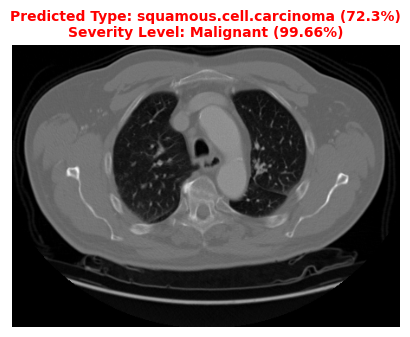

000142 (6).png -> {'type': 'squamous.cell.carcinoma', 'type_confidence': 72.3, 'severity': 'Malignant', 'severity_confidence': 99.66}


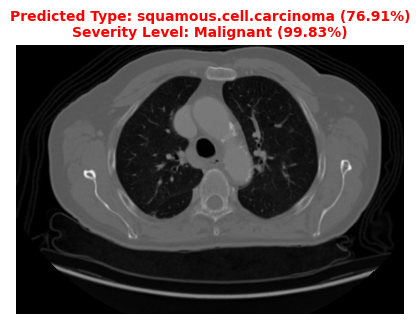

000121.png -> {'type': 'squamous.cell.carcinoma', 'type_confidence': 76.91, 'severity': 'Malignant', 'severity_confidence': 99.83}

>>> Scanning Class: NORMAL <<<


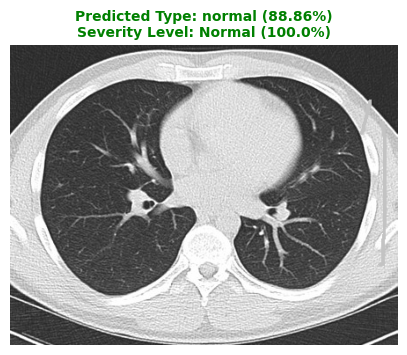

11 - Copy.png -> {'type': 'normal', 'type_confidence': 88.86, 'severity': 'Normal', 'severity_confidence': 100.0}


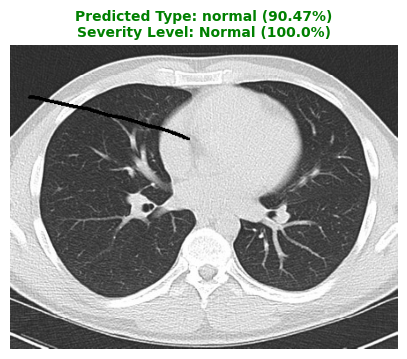

11.png -> {'type': 'normal', 'type_confidence': 90.47, 'severity': 'Normal', 'severity_confidence': 100.0}

>>> Scanning Class: ADENOCARCINOMA <<<


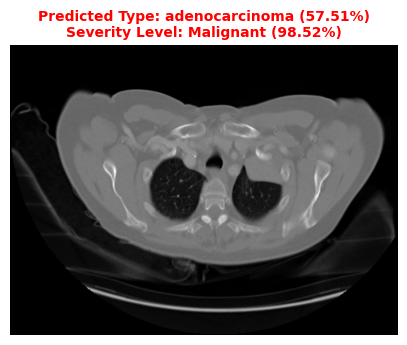

000143 (6).png -> {'type': 'adenocarcinoma', 'type_confidence': 57.51, 'severity': 'Malignant', 'severity_confidence': 98.52}


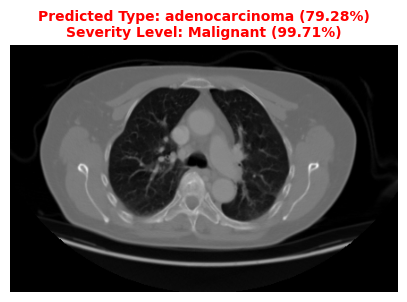

000121.png -> {'type': 'adenocarcinoma', 'type_confidence': 79.28, 'severity': 'Malignant', 'severity_confidence': 99.71}

>>> Scanning Class: LARGE.CELL.CARCINOMA <<<


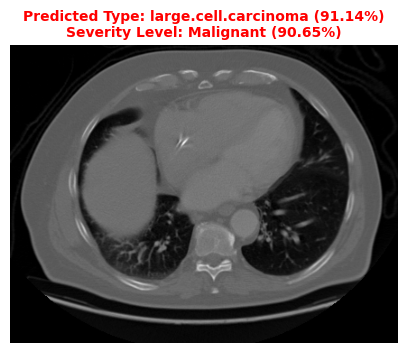

000115 (2).png -> {'type': 'large.cell.carcinoma', 'type_confidence': 91.14, 'severity': 'Malignant', 'severity_confidence': 90.65}


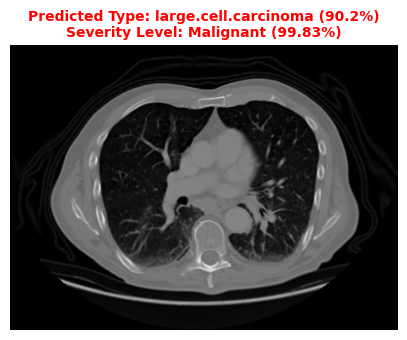

000120.png -> {'type': 'large.cell.carcinoma', 'type_confidence': 90.2, 'severity': 'Malignant', 'severity_confidence': 99.83}


In [1]:
# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input


# ============================================================
# PATHS
# ============================================================

DATASET_PATH = "/kaggle/input/chest-ctscan-images/Data/test"

TYPE_MODEL_PATH = "/kaggle/input/models/abdelazizomarrr/lung-cancer-resnet50-88acc-types/tensorflow2/default/1/Lung_Cancer_ResNet50_88Acc.keras"

SEVERITY_MODEL_PATH = "/kaggle/input/models/abdelazizomarrr/lung-cancer-severity-model/keras/default/1/Lung_Cancer_Severity_Model.h5"


# ============================================================
# INPUT SIZES (MATCH TRAINING)
# ============================================================

TYPE_INPUT_SIZE = (460, 460)
SEVERITY_INPUT_SIZE = (256, 256)


# ============================================================
# LOAD MODELS
# ============================================================

print("Loading Type Classification Model (.keras)...")
type_model = tf.keras.models.load_model(TYPE_MODEL_PATH)
print("Type model loaded successfully.")
print("Type model input shape:", type_model.input_shape)

print("\nLoading Severity Model (.h5)...")
severity_model = tf.keras.models.load_model(SEVERITY_MODEL_PATH)
print("Severity model loaded successfully.")
print("Severity model input shape:", severity_model.input_shape)


# ============================================================
# CLASS LABELS
# ============================================================

type_classes = [
    "adenocarcinoma",
    "large.cell.carcinoma",
    "normal",
    "squamous.cell.carcinoma"
]

severity_classes = [
    "Normal",
    "Benign",
    "Malignant"
]


# ============================================================
# PREPROCESSING FUNCTIONS
# ============================================================

def preprocess_for_type(img_path):
    """
    Preprocessing for Type Model (ResNet50 - RGB)
    """
    img = image.load_img(
        img_path,
        target_size=TYPE_INPUT_SIZE,
        color_mode="rgb"
    )

    x = image.img_to_array(img)
    x = preprocess_input(x)

    return np.expand_dims(x, axis=0)


def preprocess_for_severity(img_path):
    """
    Preprocessing for Severity Model (RGB - 3 Channels)
    """
    img = image.load_img(
        img_path,
        target_size=SEVERITY_INPUT_SIZE,
        color_mode="rgb"
    )

    x = image.img_to_array(img) / 255.0

    return np.expand_dims(x, axis=0)


# ============================================================
# PREDICTION FUNCTION (WITH CLINICAL LOGIC FIX)
# ============================================================

def predict_image(img_path):

    # ---- Stage 1: Type Prediction ----
    type_img = preprocess_for_type(img_path)
    type_pred = type_model.predict(type_img, verbose=0)

    predicted_type = type_classes[np.argmax(type_pred)]
    type_conf = round(float(np.max(type_pred)) * 100, 2)

    # ===== Clinical Logic Rule =====
    # If image is Normal → severity must be Normal
    if predicted_type == "normal":
        return {
            "type": predicted_type,
            "type_confidence": type_conf,
            "severity": "Normal",
            "severity_confidence": 100.0
        }

    # ---- Stage 2: Severity Prediction (only if not normal) ----
    sev_img = preprocess_for_severity(img_path)
    severity_pred = severity_model.predict(sev_img, verbose=0)

    predicted_severity = severity_classes[np.argmax(severity_pred)]
    severity_conf = round(float(np.max(severity_pred)) * 100, 2)

    return {
        "type": predicted_type,
        "type_confidence": type_conf,
        "severity": predicted_severity,
        "severity_confidence": severity_conf
    }


# ============================================================
# VISUAL DIAGNOSTIC TEST
# ============================================================

def run_diagnostic_test(num_images_per_class=2):

    if not os.path.exists(DATASET_PATH):
        print(f"Dataset not found at {DATASET_PATH}")
        return

    for class_folder in os.listdir(DATASET_PATH):

        class_path = os.path.join(DATASET_PATH, class_folder)

        if not os.path.isdir(class_path):
            continue

        print(f"\n>>> Scanning Class: {class_folder.upper()} <<<")

        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

        for img_name in images[:num_images_per_class]:

            img_path = os.path.join(class_path, img_name)

            result = predict_image(img_path)

            img_display = image.load_img(img_path)

            plt.figure(figsize=(5, 5))
            plt.imshow(img_display)
            plt.axis("off")

            title = (
                f"Predicted Type: {result['type']} ({result['type_confidence']}%)\n"
                f"Severity Level: {result['severity']} ({result['severity_confidence']}%)"
            )

            color = 'red' if result['severity'] == "Malignant" else 'green'

            plt.title(title, fontsize=10, fontweight='bold', color=color)
            plt.show()

            print(f"{img_name} -> {result}")


# ============================================================
# EXECUTION
# ============================================================

if __name__ == "__main__":
    run_diagnostic_test(num_images_per_class=2)


## Pipeline Output Interpretation

The pipeline provides a comprehensive diagnostic report by combining cancer type identification and severity estimation.
This approach supports radiologists by offering interpretable, image-based insights without replacing clinical decision-making.
